<a href="https://colab.research.google.com/github/tank550/Weather-Trend-Forecasting/blob/data_science/Weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction



<div style="text-align: center;">
    <img src="https://kajabi-storefronts-production.kajabi-cdn.com/kajabi-storefronts-production/themes/3332028/settings_images/V4Ra1KITLGxjVd7Xy0rw_file.jpg" alt="Centered Image">
</div>




# Weather Trend Forecasting
### PM Accelerator Tech Assessment

**PM Accelerator mission:** PM Accelerator supports aspiring and current product professionals — including AI/data practitioners — in building real, hands-on portfolio projects and developing the skills needed to break into and grow in tech careers, backed by mentorship and an active community.

---


**General Objective**

> Analyze global weather data from the `GlobalWeatherRepository.csv` dataset to identify trends, understand relationships between variables, and develop a model for forecasting weather conditions.

**Specific Objectives**

- Clean and prepare the data for analysis.
- Perform an exploratory data analysis (EDA) to identify trends and relationships between variables.
- Visualize the main characteristics of the data (temperature, precipitation, etc.).
- Build and evaluate one or more forecasting models using the `last_updated` variable.
- Compare the performance of the models and interpret the results.
- Conduct additional analyses such as anomaly detection, feature importance analysis, or spatial analysis.



## Install Package don't exist

In [ ]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn
!pip install kagglehub

## Importing Libraries

In [ ]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import kagglehub
import warnings
warnings.filterwarnings("ignore")
sns.set_style("darkgrid", {"grid.color": ".6",
                           "grid.linestyle": ":"})

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)

## Loading the Dataset

In [ ]:
# using kagglehub to download dataset
path = kagglehub.dataset_download("nelgiriyewithana/global-weather-repository")
print(path)

os.listdir(path)

df = pd.read_csv(f"{path}/GlobalWeatherRepository.csv")

Using Colab cache for faster access to the 'global-weather-repository' dataset.
/kaggle/input/global-weather-repository


## Data Cleaning & Processing

In [ ]:
# information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152607 entries, 0 to 152606
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       152607 non-null  object 
 1   location_name                 152607 non-null  object 
 2   latitude                      152607 non-null  float64
 3   longitude                     152607 non-null  float64
 4   timezone                      152607 non-null  object 
 5   last_updated_epoch            152607 non-null  int64  
 6   last_updated                  152607 non-null  object 
 7   temperature_celsius           152607 non-null  float64
 8   temperature_fahrenheit        152607 non-null  float64
 9   condition_text                152607 non-null  object 
 10  wind_mph                      152607 non-null  float64
 11  wind_kph                      152607 non-null  float64
 12  wind_degree                   152607 non-nul

In [ ]:
# change last_updated to datetime dtype
df["last_updated"] = pd.to_datetime(df["last_updated"])

print("Date range:", df['last_updated'].min(), "->", df['last_updated'].max())

Date range: 2024-05-16 01:45:00 -> 2026-07-11 18:45:00


In [ ]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [ ]:
# Missing Values/Null Values Count
df.isna().sum().sort_values(ascending=False)



,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0


In [ ]:
# duplicate check
dup_full = df.duplicated().sum()
# duplicate check with latitude, longitude and last_updated
dup_key = df.duplicated(subset=["latitude", "longitude", "last_updated"]).sum()
print("Fully duplicated rows:", dup_full)
print("Duplicated on (location_name, last_updated):", dup_key)


Fully duplicated rows: 0
Duplicated on (location_name, last_updated): 1


In [ ]:
# Show duplicate row in df
df[df.duplicated(subset=["latitude", "longitude", "last_updated"], keep=False)]

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
125208,Thailand,Nan,18.7833,100.7833,Asia/Bangkok,1771570800,2026-02-20 14:00:00,32.2,90.0,Partly Cloudy,2.7,4.3,178,S,1015.0,29.97,0.0,0.0,43,25,31.5,88.6,10.0,6.0,6.7,3.1,5.0,510.85,26.0,14.75,2.95,21.55,21.55,2,2,06:42 AM,06:19 PM,08:21 AM,08:58 PM,Waxing Crescent,6
125244,Thailand,Nan,18.7833,100.7833,Asia/Bangkok,1771570800,2026-02-20 14:00:00,32.2,90.0,Partly Cloudy,2.7,4.3,178,S,1015.0,29.97,0.0,0.0,43,25,31.5,88.6,10.0,6.0,6.7,3.1,5.0,510.85,26.0,14.75,2.95,21.55,21.55,2,2,06:30 AM,06:54 PM,09:05 AM,09:14 PM,Waxing Crescent,8


In [ ]:
# drop first duplicate occurence
df = df.drop_duplicates(subset=["latitude", "longitude", "last_updated"], keep="last")

## Recheck NaN and Null values

In [ ]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df.isin(["Nan", "NaN", "nan", "NAN", "null", "NULL", "Null"]).sum()

,0
country,0
location_name,783
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0




```
After analysis, we found 783 "Nan" values in the `location_name` column.
 Using the latitude and longitude columns, we could determine these values using reverse geocoding.
 However, after searching online using latitude and longitude,
 I realized that it's actually the city name that's "Nan" and not a mistake.
```



In [ ]:
# Count by unique Country
print(f"We have {df["country"].nunique()} countries in the dataset.")

We have 211 countries in the dataset.


In [ ]:
# Counts the number of times a country appears in the dataset.
pd.set_option('display.max_rows', None)
print(f"List of country occurrence counts \n {df['country'].value_counts()}")
pd.reset_option('display.max_rows')

List of country occurrence counts 
 country
Bulgaria                            1794
Indonesia                           1570
Thailand                            1566
Turkey                              1563
Sudan                               1563
Bolivia                             1556
Iran                                1523
Belgium                             1472
Madagascar                          1242
Vietnam                             1238
Hungary                              900
Russia                               838
Switzerland                          834
Senegal                              822
Norway                               794
Kenya                                786
Burundi                              785
Fiji Islands                         785
Chad                                 785
Vatican City                         785
Japan                                785
Malta                                785
Ukraine                              785
Yemen        

##  Standardize mixed-language country names

In [ ]:
# Based on the result from the previous cell, we observe that the dataset
# mixes country names in English, Portuguese, Russian, Arabic, German, and Chinese (e.g., "Malásia", "Польша", "火鸡").

country_name_fix = {
    'Democratic Republic of Congo': 'DR Congo',
    'Fiji Islands': 'Fiji',
    'Kyrghyzstan': 'Kyrgyzstan',
    'Cote d\'Ivoire': 'Ivory Coast',
    'Seychelles Islands': 'Seychelles',
    'USA United States of America': 'United States',
    'United States of America': 'United States',
    'Malásia': 'Malaysia',
    'Komoren': 'Comoros',
    'كولومبيا': 'Colombia',
    'Estonie': 'Estonia',
    'Гватемала': 'Guatemala',
    'Inde': 'India',
    'Letonia': 'Latvia',
    'Польша': 'Poland',
    'Mexique': 'Mexico',
    'Polônia': 'Poland',
    'Marrocos': 'Morocco',
    'Турция': 'Turkey',
    'Saudi Arabien': 'Saudi Arabia',
    'Südkorea': 'South Korea',
    'Bélgica': 'Belgium',
    'Turkménistan': 'Turkmenistan',
    '火鸡': 'Turkey',
    'Jemen': 'Yemen',
}

n_renamed = df['country'].isin(country_name_fix.keys()).sum()
n_before_country_standardize = df['country'].nunique()
df['country'] = df['country'].replace(country_name_fix)

print(f"Rows with non-English country name standardized: {n_renamed}")
print(f"Unique countries: before= {n_before_country_standardize}  after= {df['country'].nunique()}")


Rows with non-English country name standardized: 4253
Unique countries: before= 211  after= 192


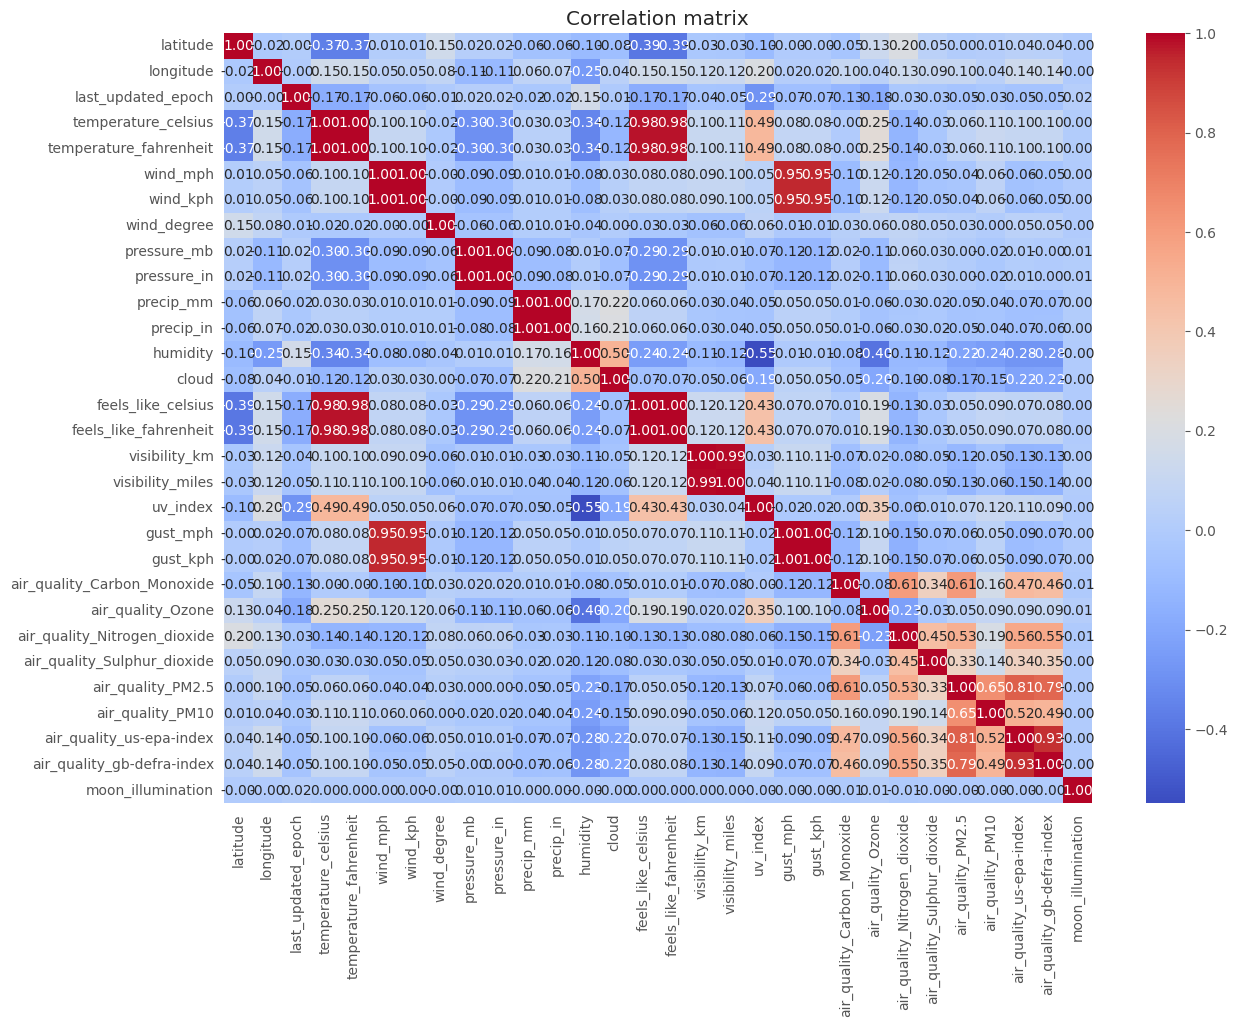

In [ ]:
# Correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

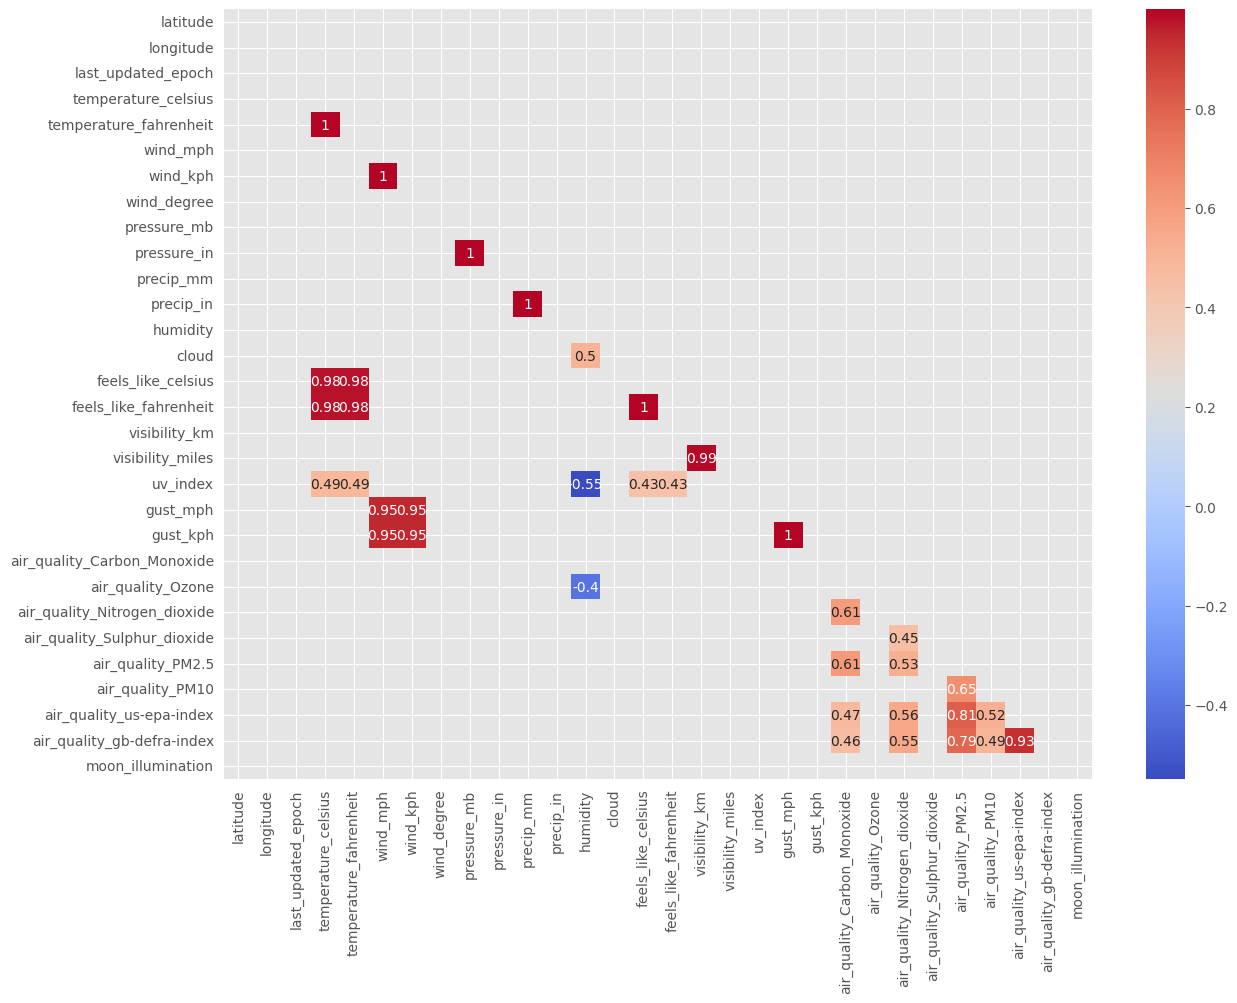

In [ ]:
# The heatmap filtered at ≥ 0.4 allows for the visualization of significant correlations.
# Among these, pairs with a correlation ≥ 0.99 are considered redundant and will be removed.

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14, 10))
corr_filtered = corr.where(np.abs(corr) >= 0.4)
sns.heatmap(corr_filtered, mask=mask, annot=True, cmap='coolwarm')
plt.show()



```
Based on the correlation matrix, we decide to remove columns deemed to be
duplicates due to a high Pearson correlation coefficient ( corr >= 0.99).
```



In [ ]:
#Based on the heatmap, these columns are redundant (corr >= 0.99)
cols_to_drop = [
    'temperature_fahrenheit',  # corr = 1.0 with temperature_celsius
    'wind_kph',                # corr = 1.0 with wind_mph
    'pressure_in',             # corr = 1.0 with pressure_mb
    'precip_in',               # corr = 1.0 with precip_mm
    'visibility_miles',        # corr = 1.0 with visibility_km
    'gust_kph',                # corr = 1.0 with gust_mph
    'feels_like_fahrenheit',   # corr = 1.0 with feels_like_celsius
]

df_after_redundant_columns = df.drop(columns=cols_to_drop)
print(f"Remaining columns: {df_after_redundant_columns.shape[1]}")

Remaining columns: 34


In [ ]:
df_after_redundant_columns.shape[1]

34

In [ ]:
df_after_redundant_columns.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_mph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338,NNW,1012.0,0.0,24,30,25.3,10.0,7.0,9.5,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,Partly cloudy,11.2,320,NW,1012.0,0.1,94,75,19.0,10.0,5.0,11.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,Sunny,15.1,280,W,1011.0,0.0,29,0,24.6,10.0,5.0,13.9,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,Light drizzle,11.9,215,SW,1007.0,0.3,61,100,3.8,2.0,2.0,8.5,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,Partly cloudy,13.0,150,SSE,1011.0,0.0,89,50,28.7,10.0,8.0,12.5,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [ ]:
# Summarize key statistics (mean, standard deviation, min, max, quartiles, etc.)
# for each numerical column, with a more readable layout

df_after_redundant_columns.describe().T

,count,mean,min,25%,50%,75%,max,std
latitude,152606.0,19.24106,-41.3,4.0503,17.25,40.4,65.3,24.399591
longitude,152606.0,21.884966,-175.2,-6.8361,23.2361,49.8822,179.22,65.778498
last_updated_epoch,152606.0,1749813707.885666,1715849100.0,1732877100.0,1749805200.0,1766733300.0,1783749600.0,19607583.820542
last_updated,152606,2025-06-13 13:31:24.812523776,2024-05-16 01:45:00,2024-11-29 12:45:00,2025-06-13 12:00:00,2025-12-26 08:15:00,2026-07-11 18:45:00,NaN
temperature_celsius,152606.0,21.347343,-29.8,16.1,23.7,27.9,79.3,9.497519
wind_kph,152606.0,12.783566,3.6,6.1,10.8,17.6,2963.2,11.27167
wind_degree,152606.0,169.563818,1.0,81.0,162.0,256.0,360.0,103.518057
pressure_mb,152606.0,1014.05796,947.0,1010.0,1014.0,1018.0,3006.0,9.970076
precip_mm,152606.0,0.131844,0.0,0.0,0.0,0.02,42.24,0.558607
humidity,152606.0,66.942623,2.0,51.0,72.0,86.0,100.0,23.642874


In [ ]:
#After reviewing the summary statistics, we noticed unrealistic air quality values that are physically impossible.
#These outliers may have been caused by faulty or damaged sensors during data collection.
#We first decided to handle the negative air quality values, as they are physically impossible.
#Positive outliers will be investigated separately with further analysis before deciding on the appropriate treatment.

air_quality_cols = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

print(f"Negative values per column: {(df_after_redundant_columns[air_quality_cols] < 0).sum()}")

total = len(df_after_redundant_columns)

# Replace negative values with NaN or impute if percentage is less than 5
for col in air_quality_cols:
    nb_neg = (df_after_redundant_columns[col] < 0).sum()
    if nb_neg > 0:
        percentage = nb_neg / total * 100
        print(f"  -> {col} : {nb_neg} negative values ({percentage:.2f}%)")
        df_after_redundant_columns[col] = df_after_redundant_columns[col].where(
            df_after_redundant_columns[col] >= 0, other=np.nan)
        if percentage < 5:
            df_after_redundant_columns = df_after_redundant_columns.dropna(subset=[col])
            print(f"     -> Less than 5% : rows dropped")
        else:
            # Median per country, not global
            median_val = df_after_redundant_columns.groupby('country')[col].transform('median')
            df_after_redundant_columns[col] = df_after_redundant_columns[col].fillna(median_val)
            print(f"     -> More than 5% : replaced by median per country")

Negative values per column: air_quality_Carbon_Monoxide     1
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
air_quality_Sulphur_dioxide     1
air_quality_PM2.5               0
air_quality_PM10                2
dtype: int64
  -> air_quality_Carbon_Monoxide : 1 negative values replaced by NaN
Percentage affected : 0.00%
  -> air_quality_Sulphur_dioxide : 1 negative values replaced by NaN
Percentage affected : 0.00%
  -> air_quality_PM10 : 2 negative values replaced by NaN
Percentage affected : 0.00%


In [ ]:
# Limites physiques réalistes
physical_limits = {
    'wind_mph': 400,       # Record mondial vent = 408 kph
    'gust_mph': 450,       # Un peu plus que wind_kph
    'pressure_mb': 1084,   # Record historique pression max
}

for col, limit in physical_limits.items():
    nb_outliers = (df_after_redundant_columns[col] > limit).sum()
    print(f"{col} : {nb_outliers} valeurs au-dessus de {limit}")
    df_after_redundant_columns[col] = df_after_redundant_columns[col].where(df_after_redundant_columns[col] <= limit, other=np.nan)

In [ ]:
df_after_redundant_columns.describe().T

,count,mean,min,25%,50%,75%,max,std
latitude,152606.0,19.24106,-41.3,4.0503,17.25,40.4,65.3,24.399591
longitude,152606.0,21.884966,-175.2,-6.8361,23.2361,49.8822,179.22,65.778498
last_updated_epoch,152606.0,1749813707.885666,1715849100.0,1732877100.0,1749805200.0,1766733300.0,1783749600.0,19607583.820542
last_updated,152606,2025-06-13 13:31:24.812523776,2024-05-16 01:45:00,2024-11-29 12:45:00,2025-06-13 12:00:00,2025-12-26 08:15:00,2026-07-11 18:45:00,NaN
temperature_celsius,152606.0,21.347343,-29.8,16.1,23.7,27.9,79.3,9.497519
wind_kph,152606.0,12.783566,3.6,6.1,10.8,17.6,2963.2,11.27167
wind_degree,152606.0,169.563818,1.0,81.0,162.0,256.0,360.0,103.518057
pressure_mb,152606.0,1014.05796,947.0,1010.0,1014.0,1018.0,3006.0,9.970076
precip_mm,152606.0,0.131844,0.0,0.0,0.0,0.02,42.24,0.558607
humidity,152606.0,66.942623,2.0,51.0,72.0,86.0,100.0,23.642874


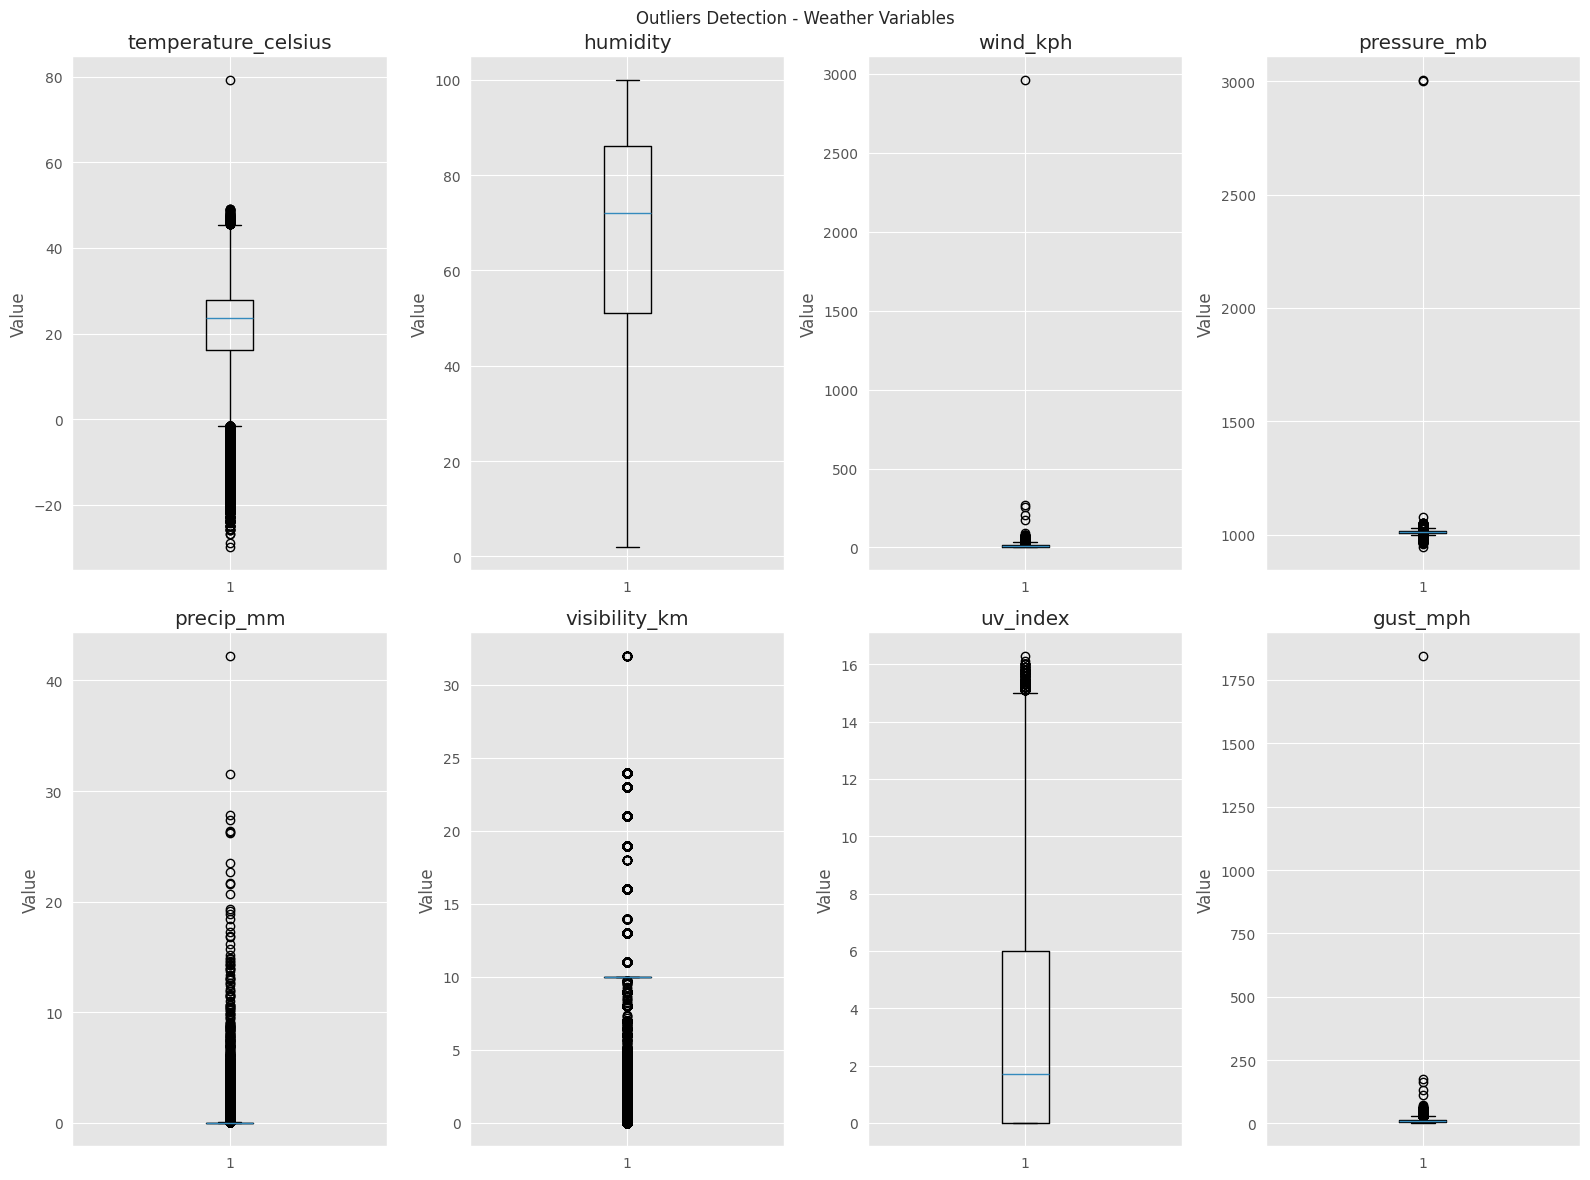

In [ ]:
# Colonnes météo principales à inspecter
meteo_cols = [
    'temperature_celsius', 'humidity', 'wind_kph',
    'pressure_mb', 'precip_mm', 'visibility_km',
    'uv_index', 'gust_mph'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(meteo_cols):
    axes[i].boxplot(df_after_redundant_columns[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Outliers Detection - Weather Variables')
plt.tight_layout()
plt.show()